# Relationship analysis
**KrishiDrishti** | Phases 4-6

Environment & resource analysis, Crop x Season and State x Season comparisons, correlations and statistical tests.

> Status: skeleton only. No analysis has been run yet.

In [2]:
# Setup: make the project root importable, then load the shared helpers
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.data_loader import load_raw
from src.io_utils import save_figure, save_table

pd.set_option("display.max_columns", 50)
df_raw = load_raw()          # untouched raw data
print(df_raw.shape)

(4000, 28)


In [5]:
df = df_raw.copy()
print(df.shape)
df.head()

(4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,7.26,5.00,5.72,4.67
Rabi,6.21,5.10,3.94,5.36
Zaid,5.85,4.03,3.06,6.17


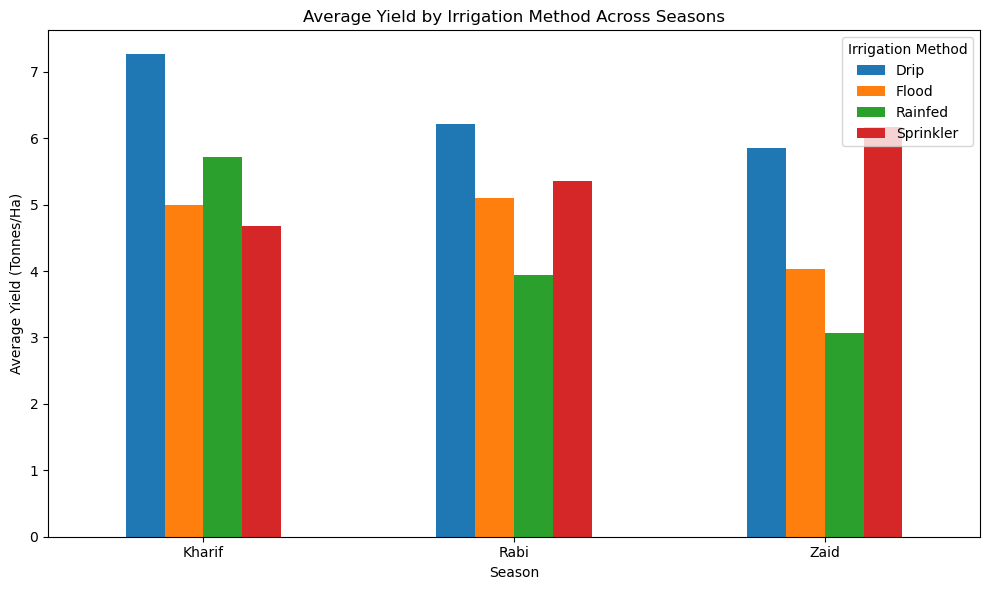

In [6]:
irrigation_season_yield = (
    df.groupby(["Season", "Irrigation_Method"])["Yield_Tonnes_Ha"]
      .mean()
      .unstack()
      .round(2)
)

display(irrigation_season_yield)

irrigation_season_yield.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Yield by Irrigation Method Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.legend(title="Irrigation Method")

plt.tight_layout()
plt.show()

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Crop,,,,
Chilli,1.72,1.49,1.44,1.50
Cotton,1.42,1.17,1.11,1.25
Groundnut,1.32,1.35,1.28,1.31
Maize,2.80,2.79,2.48,2.84
Pulses,1.05,0.88,0.86,0.89
Rice,2.77,2.24,2.36,2.49
Sugarcane,55.12,46.87,40.53,44.37
Wheat,2.30,2.03,1.98,2.23


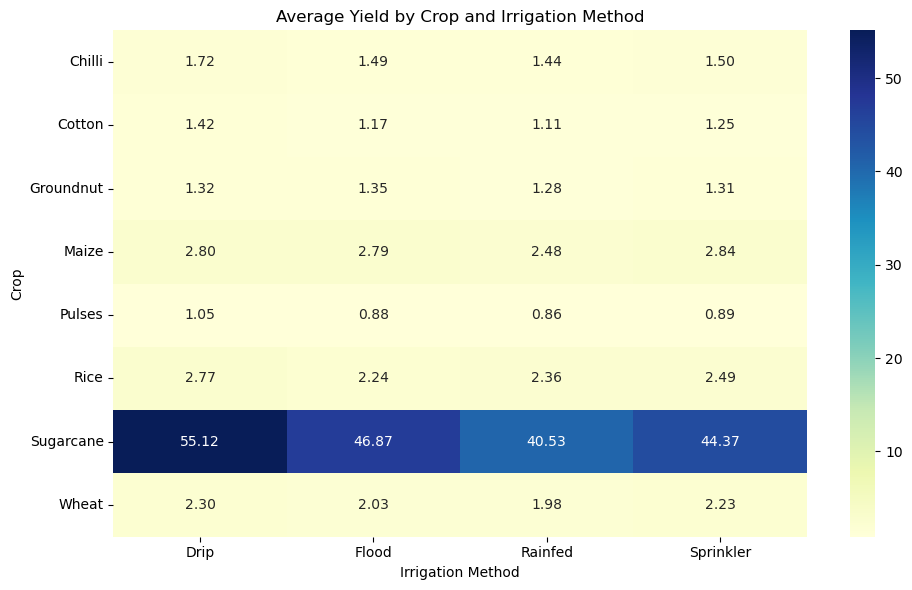

In [7]:
crop_irrigation_yield = (
    df.groupby(["Crop", "Irrigation_Method"])["Yield_Tonnes_Ha"]
      .mean()
      .unstack()
      .round(2)
)

display(crop_irrigation_yield)

plt.figure(figsize=(10, 6))
sns.heatmap(
    crop_irrigation_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Yield by Crop and Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [9]:
from scipy.stats import kruskal

groups = [
    group["Yield_Tonnes_Ha"].dropna().values
    for _, group in df.groupby("Irrigation_Method")
]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis statistic: {stat:.3f}")
print(f"p-value: {p_value:.6f}")

Kruskal-Wallis statistic: 22.439
p-value: 0.000053


In [10]:
from scipy.stats import mannwhitneyu
from itertools import combinations

methods = df["Irrigation_Method"].dropna().unique()

results = []

for method1, method2 in combinations(methods, 2):

    group1 = df.loc[
        df["Irrigation_Method"] == method1,
        "Yield_Tonnes_Ha"
    ].dropna()

    group2 = df.loc[
        df["Irrigation_Method"] == method2,
        "Yield_Tonnes_Ha"
    ].dropna()

    stat, p = mannwhitneyu(
        group1,
        group2,
        alternative="two-sided"
    )

    results.append({
        "Comparison": f"{method1} vs {method2}",
        "U_statistic": stat,
        "Raw_p_value": p
    })

pairwise_results = pd.DataFrame(results)

# Bonferroni correction for 6 pairwise comparisons
pairwise_results["Adjusted_p_value"] = (
    pairwise_results["Raw_p_value"] * len(pairwise_results)
).clip(upper=1)

display(pairwise_results.round(6))

,Comparison,U_statistic,Raw_p_value,Adjusted_p_value
0,Drip vs Flood,650967.0,0.000017,0.000101
1,Drip vs Rainfed,520062.5,0.000055,0.000332
2,Drip vs Sprinkler,351916.0,0.021763,0.130575
3,Flood vs Rainfed,668254.0,0.817938,1.000000
4,Flood vs Sprinkler,452552.0,0.128215,0.769293
5,Rainfed vs Sprinkler,363259.5,0.177640,1.000000


In [11]:
environmental_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct"
]

env_corr = df[environmental_cols + ["Yield_Tonnes_Ha"]].corr()

display(
    env_corr["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
    .round(3)
)

Yield_Tonnes_Ha       1.000
Rainfall_mm           0.031
Humidity_pct          0.011
Soil_Moisture_pct     0.010
Avg_Temperature_C     0.009
Sunlight_Hours_Day   -0.015
Name: Yield_Tonnes_Ha, dtype: float64

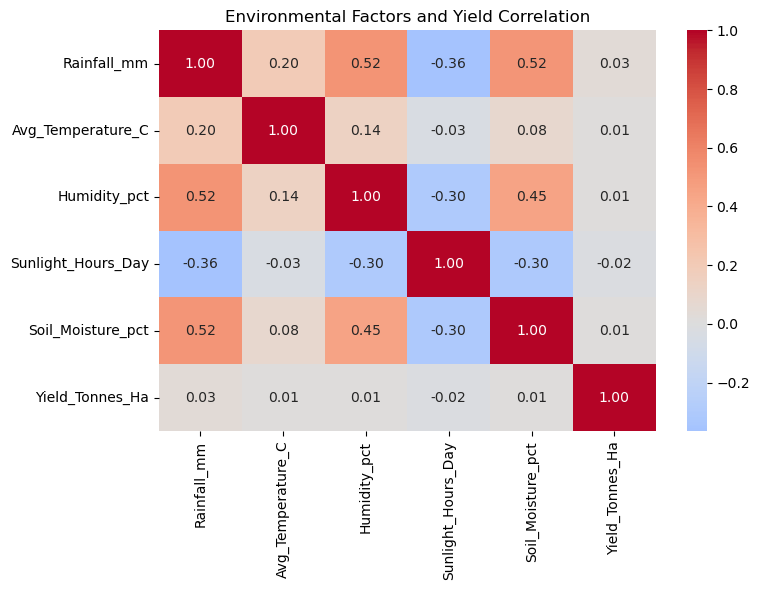

In [12]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    env_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Environmental Factors and Yield Correlation")
plt.tight_layout()
plt.show()

In [13]:
input_soil_cols = [
    "Soil_pH",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score"
]

input_soil_corr = df[input_soil_cols + ["Yield_Tonnes_Ha"]].corr()

display(
    input_soil_corr["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
    .round(3)
)

Yield_Tonnes_Ha       1.000
Nitrogen_kg_ha        0.054
Phosphorus_kg_ha      0.048
Potassium_kg_ha       0.004
Fertilizer_kg_ha      0.001
Seed_Quality_Score   -0.007
Pesticide_Litre_ha   -0.008
Soil_pH              -0.021
Name: Yield_Tonnes_Ha, dtype: float64

In [14]:
outcome_cols = [
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Efficiency_t_per_1000m3"
]

outcome_corr = df[["Yield_Tonnes_Ha"] + outcome_cols].corr()

display(
    outcome_corr["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
    .round(3)
)

Yield_Tonnes_Ha                  1.000
Water_Efficiency_t_per_1000m3    0.915
Production_Tonnes                0.885
Profit_INR                       0.490
Revenue_INR                      0.434
Name: Yield_Tonnes_Ha, dtype: float64

# KrishiDrishti — Relationship Analysis Findings

## Overview

This section documents the relationship analysis performed on the agricultural dataset to investigate how irrigation, crop type, environmental conditions, farming inputs, soil characteristics, and farm outcomes are associated with yield.

The analysis combines:

* Descriptive group comparisons
* Crop × irrigation comparisons
* Kruskal–Wallis statistical testing
* Pairwise Mann–Whitney U testing with Bonferroni correction
* Pearson correlation analysis

The results describe **associations and observed patterns** in the dataset. They should not be interpreted as proof of causal relationships.

---

# Finding 1 — Irrigation Method × Season × Yield

## Question

**Does the relationship between irrigation method and yield remain consistent across seasons?**

Average yield was compared across irrigation methods within each agricultural season.

## Results

| Season | Drip | Flood | Rainfed | Sprinkler |
| ------ | ---: | ----: | ------: | --------: |
| Kharif | 7.26 |  5.00 |    5.72 |      4.67 |
| Rabi   | 6.21 |  5.10 |    3.94 |      5.36 |
| Zaid   | 5.85 |  4.03 |    3.06 |      6.17 |

## Interpretation

The observed relationship between irrigation method and yield varies across seasons.

* **Kharif:** Drip had the highest observed average yield at **7.26 tonnes/ha**.
* **Rabi:** Drip had the highest observed average yield at **6.21 tonnes/ha**.
* **Zaid:** Sprinkler had the highest observed average yield at **6.17 tonnes/ha**.
* Rainfed farming showed relatively low average yield in Rabi and Zaid.

This indicates that the association between irrigation method and yield is not identical across all seasons.

## Limitation

These are descriptive comparisons. They do not establish that irrigation method itself causes the observed differences in yield. Other factors such as crop composition, environmental conditions, and farm characteristics may contribute.

---

# Finding 2 — Crop × Irrigation × Yield

## Question

**Does the relationship between irrigation method and yield remain consistent across crops?**

Average yield was calculated for every combination of crop and irrigation method.

## Results

| Crop      |  Drip | Flood | Rainfed | Sprinkler |
| --------- | ----: | ----: | ------: | --------: |
| Chilli    |  1.72 |  1.49 |    1.44 |      1.50 |
| Cotton    |  1.42 |  1.17 |    1.11 |      1.25 |
| Groundnut |  1.32 |  1.35 |    1.28 |      1.31 |
| Maize     |  2.80 |  2.79 |    2.48 |      2.84 |
| Pulses    |  1.05 |  0.88 |    0.86 |      0.89 |
| Rice      |  2.77 |  2.24 |    2.36 |      2.49 |
| Sugarcane | 55.12 | 46.87 |   40.53 |     44.37 |
| Wheat     |  2.30 |  2.03 |    1.98 |      2.23 |

## Interpretation

The observed irrigation–yield relationship differs across crops.

Drip had the highest observed average yield for **6 of the 8 crops**:

* Chilli
* Cotton
* Pulses
* Rice
* Sugarcane
* Wheat

There were exceptions:

* **Groundnut:** Flood had the highest observed average yield at **1.35 tonnes/ha**.
* **Maize:** Sprinkler had the highest observed average yield at **2.84 tonnes/ha**.

Therefore, the relationship between irrigation method and yield appears to depend partly on the crop being cultivated.

## Limitation

The results are descriptive and do not establish causality. Differences may also reflect other characteristics of the farms using each irrigation method.

---

# Finding 3 — Statistical Difference Across Irrigation Groups

## Question

**Are the observed yield differences between irrigation methods statistically distinguishable?**

A **Kruskal–Wallis test** was performed to compare yield distributions across the four irrigation methods.

## Results

```text
Kruskal-Wallis statistic: 22.439
p-value: 0.000053
```

## Interpretation

The p-value is substantially below the commonly used significance threshold of **0.05**.

This provides statistical evidence that the yield distributions are **not identical across all irrigation groups**.

However, the Kruskal–Wallis test only tells us that differences exist somewhere among the groups. It does **not identify which specific irrigation methods differ from one another**.

Therefore, pairwise post-hoc testing was performed.

## Limitation

The test establishes evidence of differences between groups in the observed data, but it does not establish that irrigation method causes higher or lower yield.

---

# Finding 4 — Pairwise Differences Between Irrigation Methods

## Question

**Which specific irrigation-method pairs show statistically distinguishable yield distributions?**

Following the significant Kruskal–Wallis result, pairwise **Mann–Whitney U tests** were performed.

Because six pairwise comparisons were made, **Bonferroni correction** was applied to reduce the risk of false-positive findings from multiple testing.

## Results

| Comparison           | Raw p-value | Adjusted p-value | Significant after correction? |
| -------------------- | ----------: | ---------------: | ----------------------------- |
| Drip vs Flood        |    0.000017 |     **0.000101** | Yes                           |
| Drip vs Rainfed      |    0.000055 |     **0.000332** | Yes                           |
| Drip vs Sprinkler    |    0.021763 |         0.130575 | No                            |
| Flood vs Rainfed     |    0.817938 |         1.000000 | No                            |
| Flood vs Sprinkler   |    0.128215 |         0.769293 | No                            |
| Rainfed vs Sprinkler |    0.177640 |         1.000000 | No                            |

## Interpretation

After Bonferroni correction, statistically distinguishable differences were observed for:

* **Drip vs Flood**
* **Drip vs Rainfed**

The remaining pairwise comparisons did not reach statistical significance after correction.

Notably, although the raw p-value for **Drip vs Sprinkler** was below 0.05, it became **0.130575 after Bonferroni correction**, so it is not considered statistically significant under the corrected analysis.

## Limitation

These tests identify differences in the observed yield distributions. They do not establish that the irrigation method itself caused those differences.

---

# Finding 5 — Environmental Factors and Farm-Level Yield

## Question

**How strongly are individual environmental factors linearly associated with farm-level yield?**

Pearson correlation analysis was performed between yield and:

* Rainfall
* Temperature
* Humidity
* Sunlight
* Soil moisture

## Results

| Environmental Factor | Pearson r with Yield |
| -------------------- | -------------------: |
| Rainfall             |            **0.031** |
| Humidity             |            **0.011** |
| Soil Moisture        |            **0.010** |
| Average Temperature  |            **0.009** |
| Sunlight             |           **−0.015** |

## Interpretation

All five environmental variables have correlations extremely close to zero with farm-level yield.

The strongest observed correlation was rainfall at **r = 0.031**, which is still extremely weak.

This indicates that none of the individual environmental variables shows a meaningful **linear association** with farm-level yield in this dataset.

However, the environmental variables themselves show noticeable relationships with one another.

### Environmental-variable relationships

| Relationship             | Pearson r |
| ------------------------ | --------: |
| Rainfall ↔ Humidity      |  **0.52** |
| Rainfall ↔ Soil Moisture |  **0.52** |
| Humidity ↔ Soil Moisture |  **0.45** |
| Rainfall ↔ Sunlight      | **−0.36** |
| Humidity ↔ Sunlight      | **−0.30** |
| Soil Moisture ↔ Sunlight | **−0.30** |

For example, rainfall is moderately positively associated with both humidity and soil moisture, while sunlight has moderate negative associations with rainfall, humidity, and soil moisture.

## Interpretation of the Combined Pattern

The environmental variables are therefore **not independent of one another**, even though their individual correlations with yield are very weak.

This suggests that agricultural productivity may involve combinations of environmental conditions rather than a simple one-variable relationship.

## Limitation

Pearson correlation measures **linear association**. It cannot capture:

* Nonlinear relationships
* Interactions between variables
* Crop-specific effects
* Seasonal effects
* Causal relationships

Therefore, these results should not be interpreted as evidence that environmental conditions have no effect on agricultural productivity.

---

# Finding 6 — Farming Inputs, Soil and Farm-Level Yield

## Question

**How strongly are individual soil and farming-input variables linearly associated with farm-level yield?**

Pearson correlation analysis was performed for:

* Soil pH
* Nitrogen
* Phosphorus
* Potassium
* Fertilizer usage
* Pesticide usage
* Seed quality

## Results

| Factor       | Pearson r with Yield |
| ------------ | -------------------: |
| Nitrogen     |            **0.054** |
| Phosphorus   |            **0.048** |
| Potassium    |            **0.004** |
| Fertilizer   |            **0.001** |
| Seed Quality |           **−0.007** |
| Pesticide    |           **−0.008** |
| Soil pH      |           **−0.021** |

## Interpretation

All variables show very weak or negligible linear correlations with farm-level yield.

Nitrogen had the strongest observed correlation at **r = 0.054**, but even this relationship is extremely weak.

Therefore, no individual soil or farming-input variable provides a strong linear explanation of farm-level yield variation in this dataset.

## Important Interpretation

These results should **not** be interpreted as meaning that fertilizer, nutrients, seed quality, pesticide use, or soil conditions are agriculturally irrelevant.

For example, the amount of fertilizer used may depend on the crop, season, soil condition, or expected yield. Such factors can create relationships that are more complicated than a simple one-variable correlation.

## Limitation

Pearson correlation does not capture:

* Nonlinear effects
* Crop-specific relationships
* Seasonal differences
* Interactions between inputs
* Interactions between soil and environmental conditions
* Causality

These limitations provide motivation for multivariate analysis and machine-learning approaches.

---

# Finding 7 — Yield and Economic/Resource Outcomes

## Question

**How strongly is farm-level yield associated with production, revenue, profit, and water efficiency?**

Pearson correlation analysis was performed between yield and four important farm outcomes.

## Results

| Outcome          | Pearson r with Yield |
| ---------------- | -------------------: |
| Water Efficiency |            **0.915** |
| Production       |            **0.885** |
| Profit           |            **0.490** |
| Revenue          |            **0.434** |

## Interpretation

Yield shows:

* **Very strong positive association** with water efficiency.
* **Very strong positive association** with production.
* **Moderate positive association** with profit.
* **Moderate positive association** with revenue.

This indicates that farms with higher yield tend to also have higher production and stronger economic outcomes in the observed dataset.

However, the relationships with production and water efficiency require particular caution because these variables are mathematically connected to yield.

### Production

Production is calculated using:

> **Production = Yield × Farm Area**

Therefore, the strong correlation of **0.885** is partly expected from the mathematical relationship between the variables.

### Water Efficiency

Water efficiency is calculated using production and water usage:

> **Water Efficiency = Production / Water Used × 1000**

Since production itself depends on yield, the very strong correlation of **0.915** is also partly driven by the formula.

Therefore, these should not be presented as independent discoveries that yield automatically causes higher water efficiency or production.

### Profit and Revenue

The relationships with profit and revenue are more informative because these outcomes also depend on other variables.

Revenue depends on factors such as:

* Production
* Market price

Profit additionally depends on:

* Revenue
* Total cost

Therefore, yield is only one component of the economic outcome.

## Limitation

These correlations describe associations and do not establish causality.

The strong correlations with production and water efficiency are also partly expected because of the mathematical formulas used to calculate those variables.

---

# Overall Relationship Analysis Summary

The seven analyses reveal several important patterns in the agricultural dataset.

### 1. Irrigation and season

The observed relationship between irrigation method and yield varies by season. Drip had the highest observed average yield in Kharif and Rabi, while Sprinkler had the highest observed average in Zaid.

### 2. Irrigation and crop

The relationship also varies across crops. Drip had the highest observed average for 6 of 8 crops, while Groundnut and Maize showed different highest-yield irrigation methods.

### 3. Statistical evidence

The Kruskal–Wallis test provided statistical evidence that yield distributions differ across irrigation groups.

### 4. Pairwise statistical differences

After Bonferroni correction, significant pairwise differences were observed between:

* Drip and Flood
* Drip and Rainfed

Other pairwise comparisons were not statistically significant after correction.

### 5. Environmental variables

Individual environmental variables showed **very weak linear correlations with yield**, despite moderate relationships among the environmental variables themselves.

### 6. Soil and farming inputs

Individual soil and input variables also showed **very weak linear correlations with yield**.

### 7. Farm outcomes

Yield showed strong associations with production and calculated water efficiency, and moderate associations with revenue and profit. The first two relationships are partly expected because of the formulas used to calculate those variables.

---

# Key Analytical Insight

> **Simple one-variable correlations provide limited explanation of farm-level yield variation, while contextual factors such as irrigation and season reveal more structured differences. This suggests that agricultural productivity is influenced by combinations of interacting factors rather than isolated variables.**

This provides a strong analytical motivation for the next phase of **KrishiDrishti**:

```text
Relationship Analysis
        ↓
Simple relationships reveal limited individual effects
        ↓
Contextual differences appear across irrigation / season / crop
        ↓
Agricultural outcomes depend on multiple interacting variables
        ↓
Multivariate Machine Learning
        ↓
Yield Prediction
        ↓
Feature Importance
        ↓
Explainable AI
        ↓
What-If Analysis
```

